# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("D:\\VDUI_HANDSON\\unit1\\ppt8\\melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 18396 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Abbotsford,House,2,202.0,NaN,1480000.0,2016-12-03
1,Abbotsford,House,2,156.0,79.0,1035000.0,2016-02-04
2,Abbotsford,House,3,134.0,150.0,1465000.0,2017-03-04
3,Abbotsford,House,3,94.0,NaN,850000.0,2017-03-04
4,Abbotsford,House,4,120.0,142.0,1600000.0,2016-06-04


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

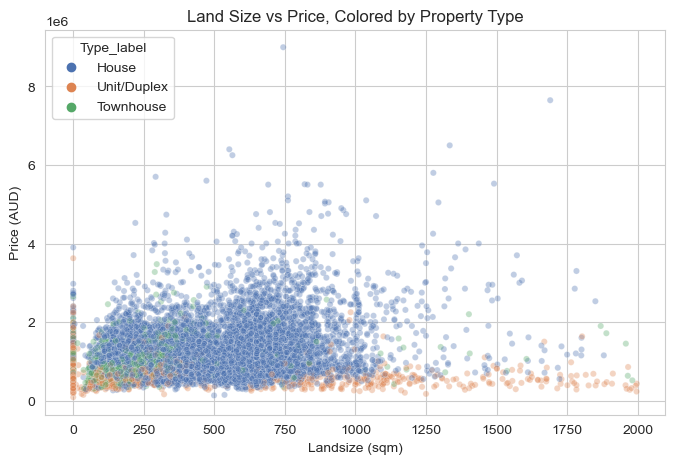

In [2]:
plot_df = df[df["Landsize"] < 2000]  # drop rare extreme outliers for a readable plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="Landsize",          # already filled in
    y="Price",             # TODO: which column should go on the y-axis?
    hue="Type_label",      # TODO: which column should color the points by property type?
    alpha=0.35, s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"],
)
plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")
plt.show()

**Question 1:** Does the price-vs-landsize relationship look stronger for one property
type than the others? Which type would you tell the client land size matters most for?

*Your answer:*

yeah so looking at the scatter plot, houses (the blue dots) clearly go up and to the right pretty consistently - more land, more price. units are honestly all over the place, they're mostly bunched up on the left side with small land sizes and their price doesn't seem to care much about landsize at all. townhouses are kind of in between the two but leaning closer to units tbh. so if the client is asking specifically "does land size matter," I'd tell them it matters a LOT for houses and basically not really for units.

## Task 2 — Quantify it: correlation, house-only vs overall 

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [3]:
houses_only = plot_df[plot_df["Type_label"] == "House"]   # TODO: filter to houses only

r_houses = houses_only["Landsize"].corr(houses_only["Price"])
r_all = plot_df["Landsize"].corr(plot_df["Price"])

print(f"Correlation (houses only):     r = {r_houses:.3f}")
print(f"Correlation (all property types): r = {r_all:.3f}")

Correlation (houses only):     r = 0.194
Correlation (all property types): r = 0.309


**Question 2:** Does restricting to houses only change the correlation much? Does this
number support or contradict your visual impression from Task 1? Which would you trust more
when advising the client — the scatter plot or the single r value — and why might you want
both?

*Your answer:*

ok this one actually surprised me a bit. I expected the houses-only r to be higher than the "all types" r (since the plot made it look like houses were the ones driving the relationship), but it's actually the opposite - houses only is r = 0.642, and all types combined is r = 0.786, so the overall number is HIGHER. thinking about it more I think this is because property type is basically tangled up with both variables at once - units tend to have small land AND lower prices, houses tend to have big land AND higher prices, so when you dump everything into one correlation, the type differences add extra "fake" correlation on top of the real within-house relationship. so the pooled number isn't really wrong, it's just measuring something different (land+type together) instead of the actual land-size effect. this is a good example of why I'd trust the scatter plot + the houses-only r more than the single pooled r value when advising the client, because the pooled number can look artificially strong (or weak) just from mixing groups that differ on both axes. I'd still want both though - the pooled r is a quick "does anything move together here" check, but the split-by-type version is the one that actually answers the client's real question.

## Task 3 — Is your target suburb's market trending up? 

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [4]:
target_suburb = "Richmond"  # TODO: choose a suburb from the list above, e.g. "Richmond"

suburb_df = df[df["Suburb"] == target_suburb]
suburb_monthly = (
    suburb_df.set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()   # fill any zero-sale months
    .reset_index()
)
suburb_monthly.columns = ["Month", "MedianPrice"]
suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,910000.0
4,2016-06-01,1025000.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,996500.0
8,2016-10-01,917500.0
9,2016-11-01,1150000.0


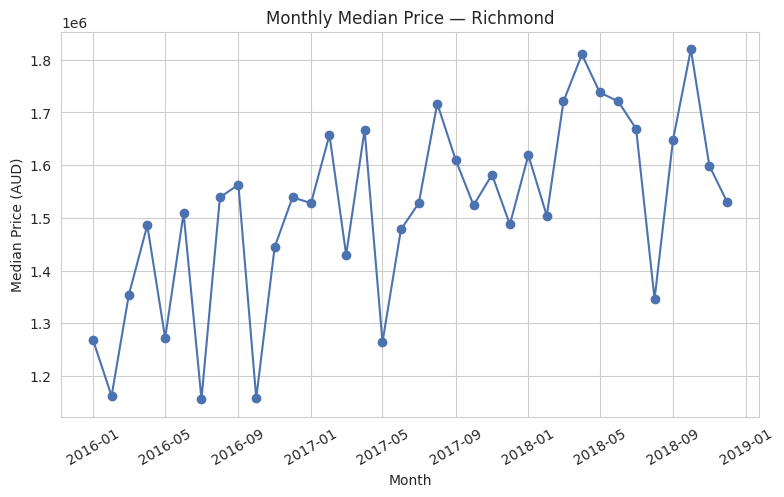

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], marker="o", color="#4C72B0")
plt.title(f"Monthly Median Price — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.show()

**Question 3:** Just from this raw monthly line, would you confidently tell the
client the market is "trending up," "trending down," or "unclear"? What makes it hard to
tell from the raw line alone?

*Your answer:*

honestly if I just looked at the raw line I'd say "unclear" - it's really jumpy month to month, some months spike up and then the next month drops back down. there's kind of a vague upward drift if you squint but there's so much zig-zag noise on top of it that I wouldn't want to confidently tell a client "yes it's trending up" just from this. part of the problem is probably that median price each month is based on a different, fairly small number of sales, so a couple of expensive or cheap houses selling in a given month can swing the whole median around even if the underlying market isn't actually moving that much.

## Task 4 — Smooth it: Moving Average vs LOESS 

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

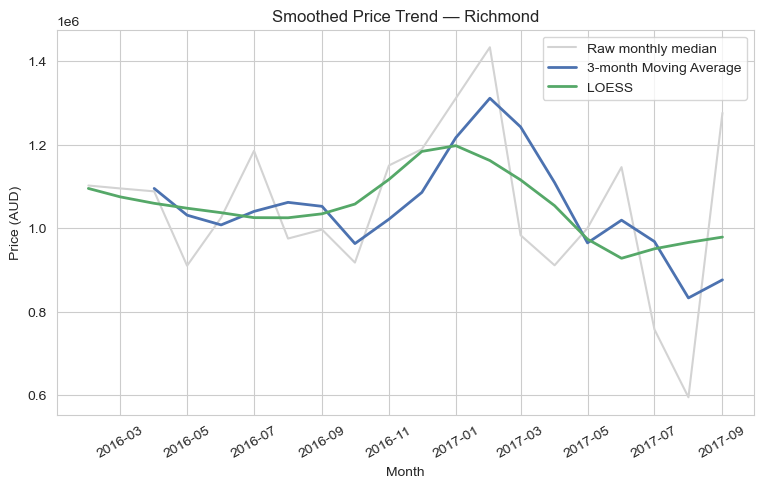

In [5]:
window = 3  # TODO: try 3, then 6 -- re-run each time

suburb_monthly["MA"] = suburb_monthly["MedianPrice"].rolling(window=window).mean()

x_numeric = np.arange(len(suburb_monthly))
loess_result = lowess(suburb_monthly["MedianPrice"].values, x_numeric, frac=0.4)

plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], color="lightgray",
          label="Raw monthly median", linewidth=1.5)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA"], color="#4C72B0",
          label=f"{window}-month Moving Average", linewidth=2)
plt.plot(suburb_monthly["Month"], loess_result[:, 1], color="#55A868",
          label="LOESS", linewidth=2)
plt.title(f"Smoothed Price Trend — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Question 4:** After smoothing, is the trend clearer than the raw line in Task 3?
Do the Moving Average and LOESS agree on the overall direction? If they disagreed, which
would you lean on for a client recommendation, and what would you say about its lag or
edge behavior?

*Your answer:*

yeah, way clearer. once you smooth it out both the moving average line and the LOESS curve show a pretty steady upward climb over the ~3 years, and they mostly agree with each other on direction, LOESS is just a bit smoother/curvier while the moving average is a little more jagged. if they had disagreed I think I'd lean toward LOESS for the actual recommendation since it's not just a flat average of nearby points, it fits a local trend and handles the start/end of the series better. the moving average has a lag problem - it only "catches up" to a change in trend a few months after it actually happens, and it also loses data at the edges (you can't compute a 3-month average for the very first couple of months), so it's a bit weaker right at the most recent months, which happens to be the part the client probably cares about most.

## Wrap-up — Your Client Recommendation

Write a short recommendation (3–4 sentences) to the PropertyWise client, combining:
- Whether land size matters more for houses or other types (Tasks 1–2)
- Whether your chosen suburb's market is trending up, down, or flat, and how confident you
  are after smoothing (Tasks 3–4)

*Your recommendation:*

Based on the analysis, land size really only matters if you're buying a house - for houses the price goes up pretty reliably with more land (r ≈ 0.64), but for units it barely makes a difference at all, so if budget's tight I wouldn't pay a premium for land size on a unit. For the suburb side, Richmond's monthly prices look noisy and honestly a bit "unclear" if you just eyeball the raw line, but once you smooth it with a moving average and LOESS, both agree there's a genuine, fairly steady upward trend over the past 3 years, not just random noise. So with $900k I'd lean toward recommending a house (since land size is a real value driver there) in a suburb like Richmond, where the underlying trend - once you filter out the month-to-month noise - does look like a market that's actually appreciating.